## Import Libraries

In [1]:
import os
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image

plt.style.use('ggplot')

## Dataset Path

In [ ]:
dataset_path = Path("../dataset")

train_dir = dataset_path / "train"
test_dir = dataset_path / "test"

print("Train Path:", train_dir)
print("Test Path :", test_dir)



Train Path: ..\dataset\Train
Test Path : ..\dataset\Test


## List all classes

In [7]:
classes = sorted(os.listdir(train_dir))

print('number of classes:', len(classes))


number of classes: 22


In [8]:
for cls in classes:
    print(cls)

Acne
Actinic_Keratosis
Benign_tumors
Bullous
Candidiasis
DrugEruption
Eczema
Infestations_Bites
Lichen
Lupus
Moles
Psoriasis
Rosacea
Seborrh_Keratoses
SkinCancer
Sun_Sunlight_Damage
Tinea
Unknown_Normal
Vascular_Tumors
Vasculitis
Vitiligo
Warts


## Count Images in Each Class


In [9]:
train_counts = []

for cls in classes:
    folder = train_dir / cls
    count = len(os.listdir(folder))

    train_counts.append([cls, count])

train_df = pd.DataFrame(train_counts, columns=['Disease', 'Images'])

train_df

,Disease,Images
0,Acne,593
1,Actinic_Keratosis,748
2,Benign_tumors,1093
3,Bullous,504
4,Candidiasis,248
5,DrugEruption,547
6,Eczema,1010
7,Infestations_Bites,524
8,Lichen,553
9,Lupus,311


## Plot Class Distribution

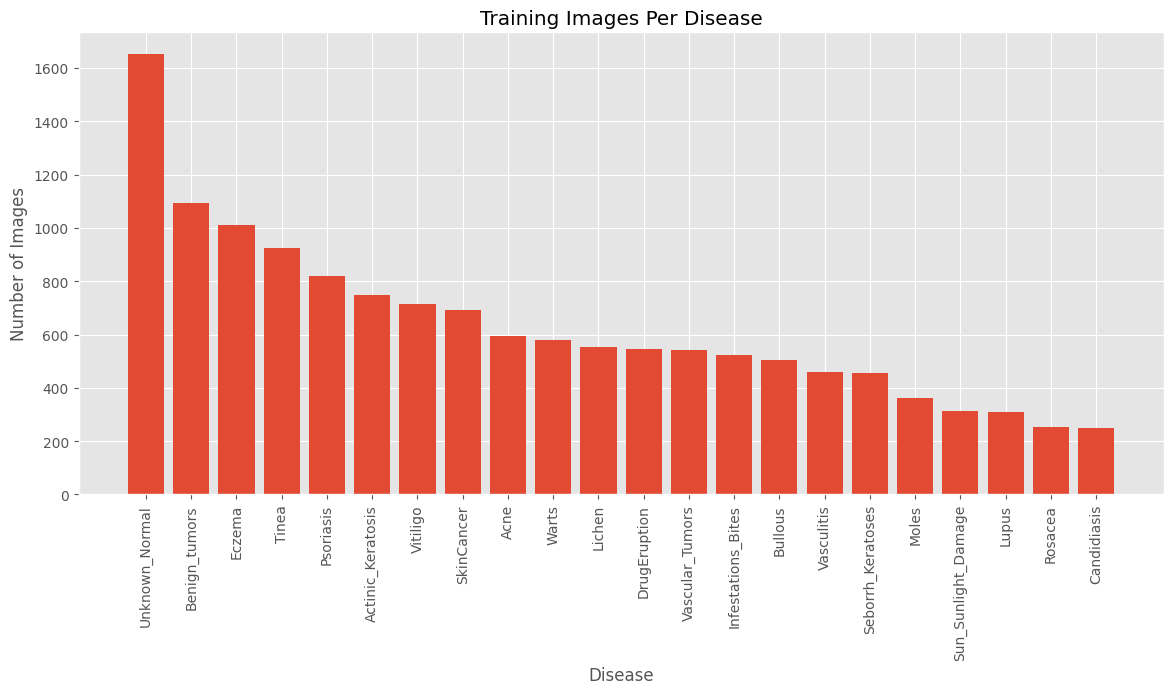

In [13]:
plt.figure(figsize=(14,6))

plt.bar(train_df["Disease"], train_df["Images"])

plt.xticks(rotation=90)

plt.xlabel("Disease")

plt.ylabel("Number of Images")

plt.title("Training Images Per Disease")

plt.show()

## Count Total Images

In [15]:
print('Total Classes :', len(classes))
print('Total training images :', train_df['Images'].sum())

Total Classes : 22
Total training images : 13898


## Display Sample Images

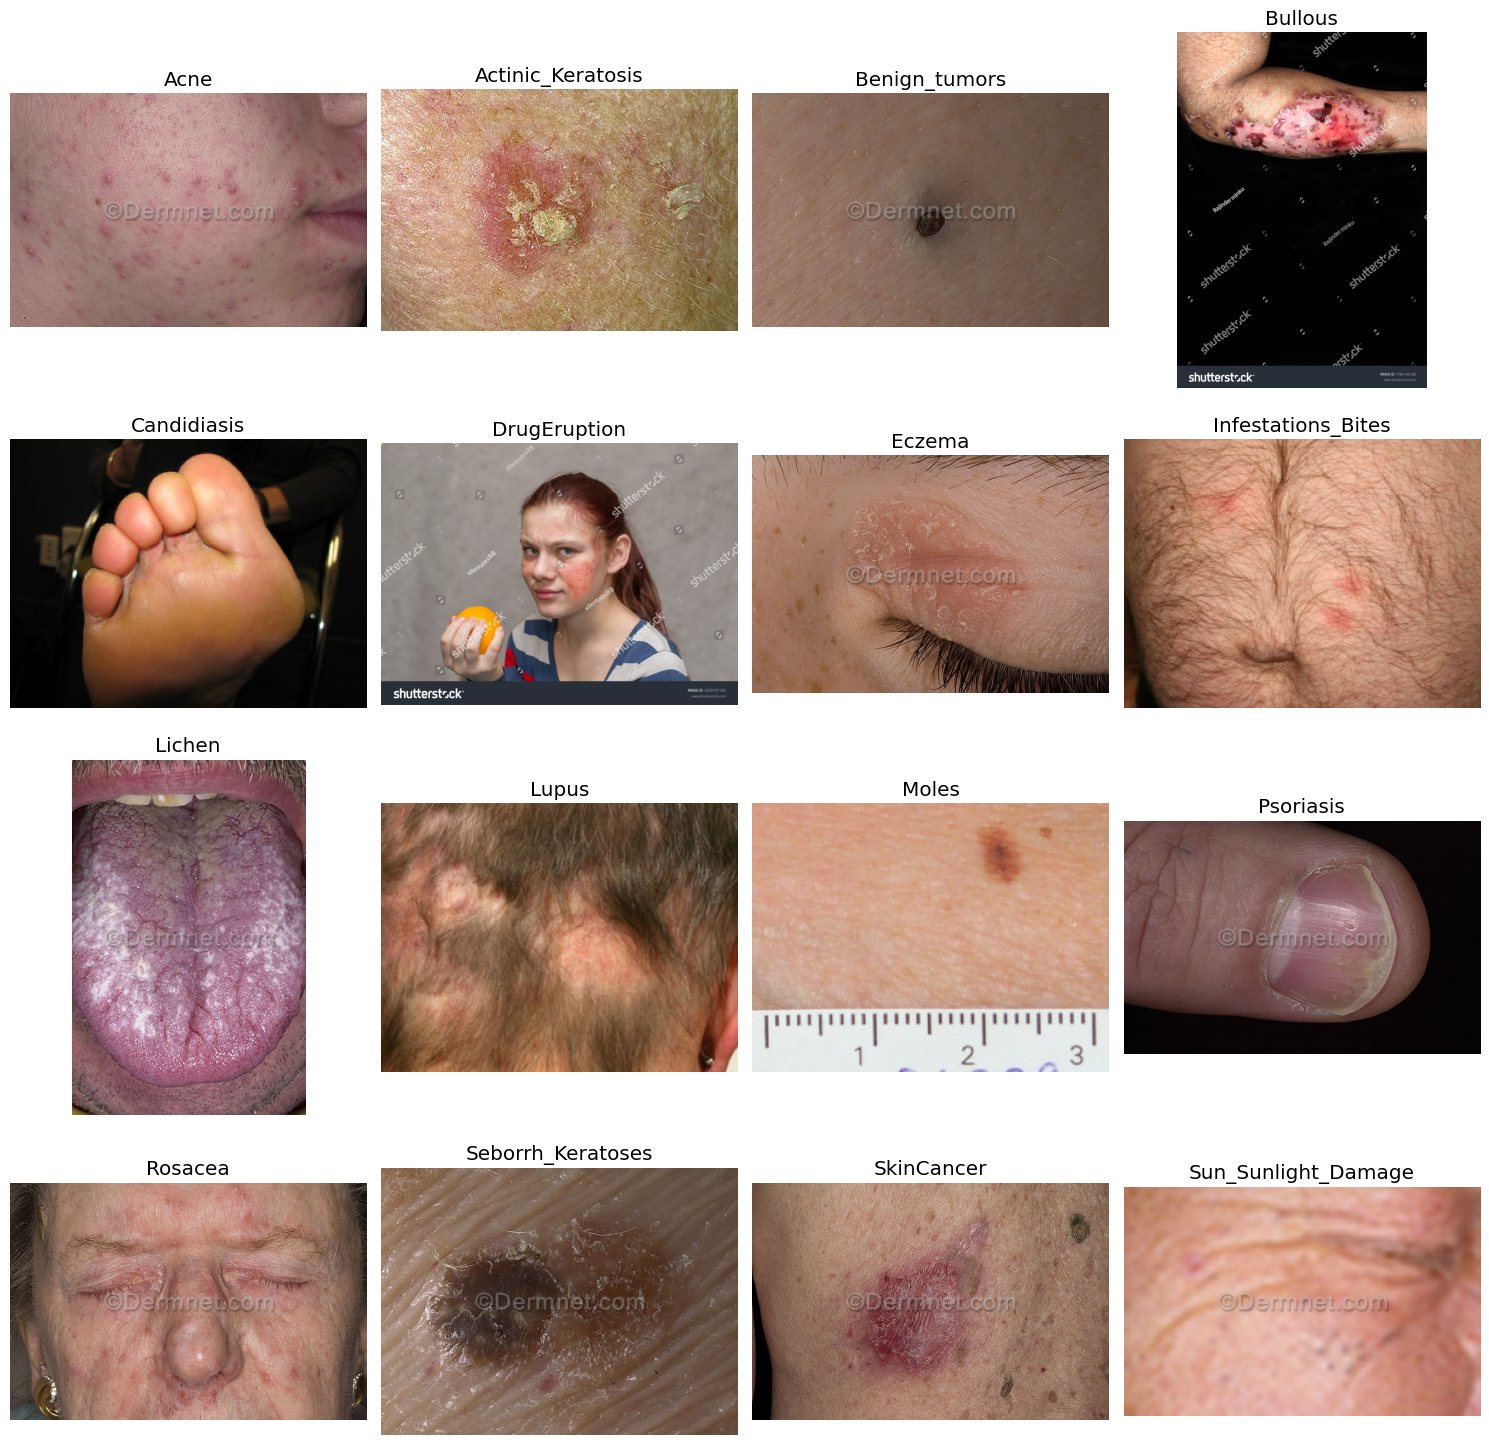

In [16]:
plt.figure(figsize=(15,15))

for i, cls in enumerate(classes[:16]):

    image_name = os.listdir(train_dir / cls)[0]

    image_path = train_dir / cls / image_name

    image = Image.open(image_path)

    plt.subplot(4,4,i+1)

    plt.imshow(image)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

## Check Image Sizes

In [17]:
widths = []
heights = []

for cls in classes:

    images = os.listdir(train_dir / cls)

    for img_name in images[:50]:

        img = Image.open(train_dir / cls / img_name)

        width, height = img.size

        widths.append(width)
        heights.append(height)

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

Minimum Width : 100
Maximum Width : 2560
Minimum Height: 100
Maximum Height: 1707


## Plot Image Size Distribution

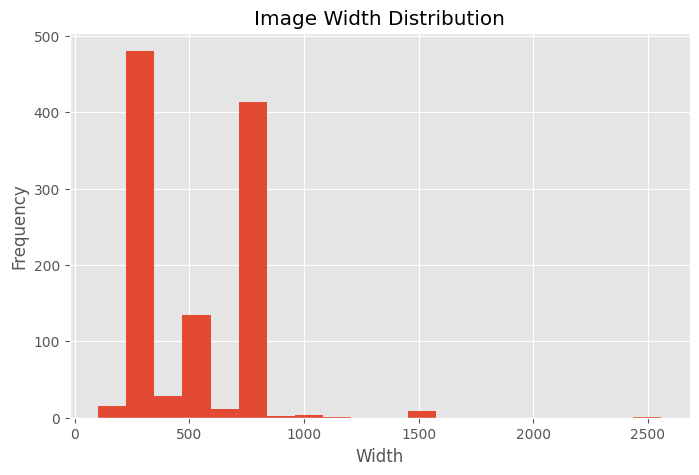

In [18]:
plt.figure(figsize=(8,5))

plt.hist(widths, bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

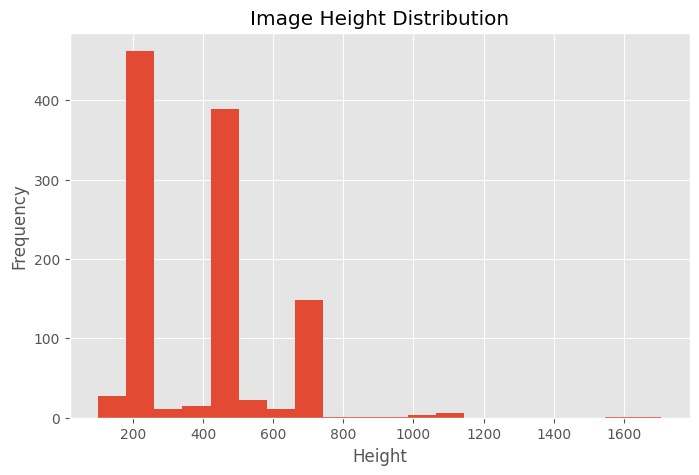

In [19]:
plt.figure(figsize=(8,5))

plt.hist(heights, bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

## Check Image Modes

In [20]:
modes = {}

for cls in classes:

    images = os.listdir(train_dir / cls)

    for img_name in images[:20]:

        img = Image.open(train_dir / cls / img_name)

        mode = img.mode

        modes[mode] = modes.get(mode, 0) + 1

modes

{'RGB': 440}

## Find Corrupted Images

In [21]:
bad_images = []

for cls in classes:

    images = os.listdir(train_dir / cls)

    for img_name in images:

        path = train_dir / cls / img_name

        try:
            img = Image.open(path)
            img.verify()

        except:
            bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


## Dataset Summary

In [22]:
summary = pd.DataFrame({

    "Total Classes":[len(classes)],

    "Training Images":[train_df["Images"].sum()],

    "Corrupted Images":[len(bad_images)],

    "Minimum Width":[min(widths)],

    "Maximum Width":[max(widths)],

    "Minimum Height":[min(heights)],

    "Maximum Height":[max(heights)]

})

summary

,Total Classes,Training Images,Corrupted Images,Minimum Width,Maximum Width,Minimum Height,Maximum Height
0,22,13898,0,100,2560,100,1707
